In [1]:
import os
import math

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

**Содержание**
1. [Загрузка данных](#Загрузка-данных)
2. [Умножение матриц](#Умножение-матриц)
3. [Алгоритм преобразования](#Алгоритм-преобразования)
4. [Проверка алгоритма](#Проверка-алгоритма)
5. [Вывод](#Вывод)

# Защита персональных данных клиентов

Вам нужно защитить данные клиентов страховой компании «Хоть потоп». Разработайте такой метод преобразования данных, чтобы по ним было сложно восстановить персональную информацию. Обоснуйте корректность его работы.

Нужно защитить данные, чтобы при преобразовании качество моделей машинного обучения не ухудшилось. Подбирать наилучшую модель не требуется.

## Загрузка данных

In [2]:
def load_dataset(name, **kwargs):
    """Читает датасет из локальной папки datasets/, при её отсутствии — с code.s3.yandex.net."""
    local = os.path.join('datasets', name)
    source = local if os.path.exists(local) else 'https://code.s3.yandex.net/datasets/' + name
    return pd.read_csv(source, **kwargs)

df = load_dataset('insurance.csv')
df.head()

,Пол,Возраст,Зарплата,Члены семьи,Страховые выплаты
0,1,41.0,49600.0,1,0
1,0,46.0,38000.0,1,1
2,0,29.0,21000.0,0,0
3,0,21.0,41700.0,2,0
4,1,28.0,26100.0,0,0


In [3]:
df.shape

(5000, 5)

In [4]:
df.describe()

,Пол,Возраст,Зарплата,Члены семьи,Страховые выплаты
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.499000,30.952800,39916.360000,1.194200,0.148000
std,0.500049,8.440807,9900.083569,1.091387,0.463183
min,0.000000,18.000000,5300.000000,0.000000,0.000000
25%,0.000000,24.000000,33300.000000,0.000000,0.000000
50%,0.000000,30.000000,40200.000000,1.000000,0.000000
75%,1.000000,37.000000,46600.000000,2.000000,0.000000
max,1.000000,65.000000,79000.000000,6.000000,5.000000


In [5]:
df.columns

Index(['Пол', 'Возраст', 'Зарплата', 'Члены семьи', 'Страховые выплаты'], dtype='str')

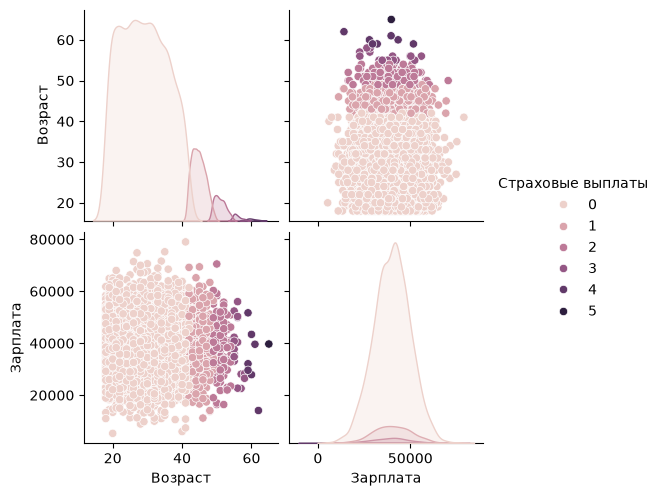

In [6]:
sns.pairplot(df[['Возраст', 'Зарплата', 'Страховые выплаты']], hue='Страховые выплаты')

## Умножение матриц

Обозначения:

- $X$ — матрица признаков (нулевой столбец состоит из единиц)

- $y$ — вектор целевого признака

- $P$ — матрица, на которую умножаются признаки

- $w$ — вектор весов линейной регрессии (нулевой элемент равен сдвигу)

Предсказания:

$$
a = Xw
$$

Задача обучения:

$$
w = \arg\min_w MSE(Xw, y)
$$

Формула обучения:

$$
w = (X^T X)^{-1} X^T y
$$

**Ответ:** Качество линейной регрессии не изменится.

**Обоснование:** Умножим признаки на обратимую матрицу $P$, тогда предсказания можно переписать в виде:

$$
a' = XPw',
$$
где $w'$ — новый вектор весов линейной регрессии (нулевой элемент равен сдвигу).

Тогда задача обучения примет вид:

$$
w' = \arg\min_{w'} MSE(XPw', y)
$$

Формула обучения:

$$
w' = ((XP)^T XP)^{-1} (XP)^T y
$$

Раскроем транспонирование произведения:

$$
w' = (P^T X^T X P)^{-1} P^T X^T y
$$

Раскроем обратную матрицу произведения (все сомножители обратимы):

$$
w' = P^{-1} (X^T X)^{-1} (P^T)^{-1} P^T X^T y
$$

Сокращаем $(P^T)^{-1} P^T = E$ (умножение матрицы на свою обратную даёт единичную матрицу):

$$
w' = P^{-1}(X^T X)^{-1} X^T y
$$

Используем подстановку $w = (X^T X)^{-1} X^T y$:

$$
w' = P^{-1}w
$$

Тогда предсказания после преобразования совпадают с исходными:

$$
a' = XPw' = XPP^{-1}w = Xw = a
$$

Мы установили однозначную взаимосвязь векторов весов исходной и преобразованной моделей: поскольку матрица $P$ обратима (а $X^TX$ невырождена), предсказания, а значит и качество линейной регрессии, не изменятся.

## Алгоритм преобразования

In [7]:
state = np.random.RandomState(12345)

In [8]:
X = df.drop('Страховые выплаты', axis=1)
y = df['Страховые выплаты']

In [9]:
class LinearRegressor:
    def transformation(self, features, random_state=12345):
        """Умножает признаки на случайную обратимую матрицу P."""
        rng = np.random.RandomState(random_state)
        n = features.shape[1]
        P = rng.normal(size=(n, n))
        # гарантируем обратимость: перегенерируем матрицу, если определитель близок к нулю
        while np.isclose(np.linalg.det(P), 0):
            P = rng.normal(size=(n, n))
        self.P = P
        return features @ P

    def fit(self, train_features, train_target):
        X = np.concatenate((np.ones((train_features.shape[0], 1)), train_features), axis=1)
        y = train_target
        w = np.linalg.inv(X.T @ X) @ X.T @ y
        self.w = w[1:]
        self.w0 = w[0]
        return self.w, self.w0

    def predict(self, features_test):
        return features_test @ self.w + self.w0

    def score(self, y_true, y_pred):
        return 1 - ((y_true - y_pred) ** 2).sum() / ((y_true - y_true.mean()) ** 2).sum()

    def cross_val(self, features, target, n_folds=3):
        """Кросс-валидация по последовательным блокам, возвращает R^2 по фолдам."""
        scores = []
        fold_size = math.ceil(len(features) / n_folds)
        for i in range(0, len(features), fold_size):
            end = min(i + fold_size, len(features))
            valid_idx = np.arange(i, end)
            train_idx = np.concatenate((np.arange(0, i), np.arange(end, len(features))))
            model = LinearRegressor()
            model.fit(features.iloc[train_idx], target.iloc[train_idx])
            predictions = model.predict(features.iloc[valid_idx])
            scores.append(model.score(target.iloc[valid_idx], predictions))
        self.final_score = sum(scores) / len(scores)
        return scores

**Обоснование**

Покажем алгоритм в действии: качество на описываемых выборках - не меняется.

In [10]:
m = LinearRegressor()
features_transformed = m.transformation(X)

In [11]:
m.cross_val(features_transformed, y)

[np.float64(0.41897383565732627),
 np.float64(0.4249089782712626),
 np.float64(0.42999751869498104)]

In [12]:
m.final_score

np.float64(0.42462677754119)

In [13]:
z = LinearRegressor()
z.cross_val(X, y)

[np.float64(0.41897383652566533),
 np.float64(0.4249089803802155),
 np.float64(0.42999752162034255)]

In [14]:
print('Качество (R^2) на преобразованной выборке:', m.final_score, '\nКачество (R^2) на исходной выборке:', z.final_score)

Качество (R^2) на преобразованной выборке: 0.42462677754119 
Качество (R^2) на исходной выборке: 0.4246267795087411


## Проверка алгоритма

Создадим случайную квадратную матрицу с подходящим под исходные данные размером. Проверим, что она не вырождена:

In [15]:
P = state.normal(size=(4, 4))
P

array([[-0.20470766,  0.47894334, -0.51943872, -0.5557303 ],
       [ 1.96578057,  1.39340583,  0.09290788,  0.28174615],
       [ 0.76902257,  1.24643474,  1.00718936, -1.29622111],
       [ 0.27499163,  0.22891288,  1.35291684,  0.88642934]])

In [16]:
np.linalg.det(P)

np.float64(-3.0255129130001897)

In [17]:
np.linalg.inv(P)

array([[-1.31136747,  0.3921804 ,  0.18868055, -0.67088287],
       [ 1.75872714,  0.14106138, -0.17773045,  0.79787127],
       [-0.41702659, -0.22854768,  0.3550602 ,  0.33039819],
       [ 0.58912996,  0.19073027, -0.5545481 ,  0.6259302 ]])

### Создадим и обучим стандартные модели линейной регрессии из sklearn на исходных и преобразованных данных. Затем сравним кросс валидацией качество моделей:

In [18]:
model1 = LinearRegression()
cross_val_score(model1, X, y, cv=10).mean()

np.float64(0.41460084738601377)

In [19]:
model2 = LinearRegression()
cross_val_score(model2, X @ P, y, cv=10).mean()

np.float64(0.41460084738586345)

## Вывод:
Разработан и обоснован алгоритм защиты персональных данных: умножение матрицы признаков на случайную обратимую матрицу $P$.

- Теоретически доказано, что предсказания линейной регрессии при таком преобразовании не меняются ($w' = P^{-1}w$).
- Практически подтверждено: R² на кросс-валидации совпадает для исходных и преобразованных данных как для собственной реализации, так и для `sklearn.LinearRegression`.
- Восстановить исходные данные без знания матрицы $P$ затруднительно, при этом качество модели не ухудшается.